<a href="https://colab.research.google.com/github/sushantbiju/AI_lab/blob/main/Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Binary Classification – Circles Dataset (PyTorch)

**Objective:**  


1.   To build and compare simple feed-forward neural networks to classify two concentric circles.
2.   To show the importance of non-linearity (ReLU) in solving non-linearly separable problems.


  
## 1. Data Retrieval & Inspection

In [3]:
import pandas as pd
df = pd.read_csv("circles_binary_classification.csv")


print("First 5 rows:")
display(df.head())

print("\nDescription:")
display(df.describe())


First 5 rows:


,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0



Description:


,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,-0.000448,-0.000804,0.50000
std,0.639837,0.641156,0.50025
min,-1.059502,-1.067768,0.00000
25%,-0.619251,-0.612176,0.00000
50%,0.008762,-0.003949,0.50000
75%,0.621933,0.624822,1.00000
max,1.033712,1.036004,1.00000


Here, we load the CSV file with pandas then display the first 5 rows and generate summary statistics for data analysis.


## 2. Data Cleaning & Feature Design

In [4]:
df.isnull().sum()


,0
X1,0
X2,0
label,0


In [5]:
df.duplicated().sum()
data = df.drop_duplicates()


In [6]:
import torch
import numpy as np

X_np = df[['X1', 'X2']].values
y_np = df['label'].values

X = torch.from_numpy(X_np).type(torch.float32)
y = torch.from_numpy(y_np).type(torch.float32)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: torch.Size([1000, 2])
y shape: torch.Size([1000])


In this phase, we have cleaned the dataset by removing the duplicate and checking null values. We also separated the features and labels after which the data were converted into tensor format making ready for training a Pytorch model.

## 3. Visualize Data

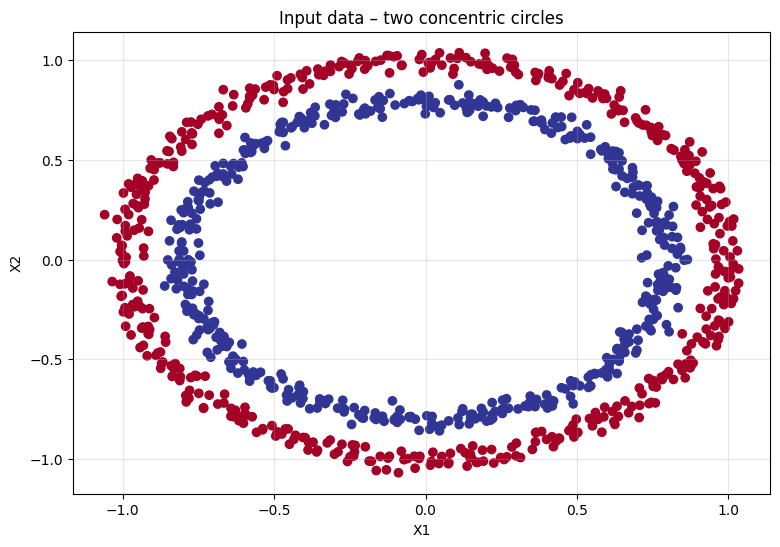

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,6))
plt.scatter(x=data.X1,
            y=data.X2,
            c=data.label,
            cmap=plt.cm.RdYlBu
            );
plt.title("Input data – two concentric circles")
plt.xlabel("X1"); plt.ylabel("X2")
plt.grid(alpha=0.3)
plt.show()

We clearly see that the problem is not linearly separable so a linear model or network without activation functions will not succeed.

In [8]:
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from timeit import default_timer as timer

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train Size:{len(X_train)}, {len(X_test)}", f"\nTest Size: {len(y_train)}, {len(y_test)}")


Train Size:800, 200 
Test Size: 800, 200


## 5. Device & dtype

In [9]:
import torch
from torch import nn
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# Move data to device
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)
y_test  = y_test.to(device)

Using device: cuda


Setup Training

In [10]:
def accuracy_fn(y_true, y_pred):
 correct = torch.eq(y_true, y_pred).sum().item()
 acc = (correct / len(y_pred)) * 100
 return acc
def train_and_test_loop(model, epochs, loss_fn, optimizer,
name="Model"):
 print(f"\nTraining {name} for {epochs} epochs...")
 train_losses, test_losses = [], []
 model.to(device)
 for epoch in range(epochs):
    model.train()
    y_logits = model(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
 ### Testing
    model.eval()
    with torch.inference_mode():
      test_logits = model(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))
      test_loss = loss_fn(test_logits, y_test)
      test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)
      train_losses.append(loss.item())
      test_losses.append(test_loss.item())
      if epoch % (epochs // 10) == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc:.2f}%")

 return train_losses, test_losses

## 6. Model Definitions
ModelV0:: 2 -> 5 -> 1 (No Activation)


Training ModelV0 for 100 epochs...
Epoch: 0 | Loss: 0.70019, Acc: 42.88% | Test Loss: 0.70578, Test Acc: 41.00%
Epoch: 10 | Loss: 0.69636, Acc: 46.25% | Test Loss: 0.70177, Test Acc: 47.50%
Epoch: 20 | Loss: 0.69470, Acc: 48.62% | Test Loss: 0.69975, Test Acc: 46.50%
Epoch: 30 | Loss: 0.69394, Acc: 49.00% | Test Loss: 0.69861, Test Acc: 47.00%
Epoch: 40 | Loss: 0.69358, Acc: 49.50% | Test Loss: 0.69786, Test Acc: 46.00%
Epoch: 50 | Loss: 0.69338, Acc: 50.12% | Test Loss: 0.69733, Test Acc: 46.50%
Epoch: 60 | Loss: 0.69326, Acc: 50.38% | Test Loss: 0.69692, Test Acc: 46.00%
Epoch: 70 | Loss: 0.69319, Acc: 50.75% | Test Loss: 0.69659, Test Acc: 47.00%
Epoch: 80 | Loss: 0.69314, Acc: 50.25% | Test Loss: 0.69632, Test Acc: 47.00%
Epoch: 90 | Loss: 0.69310, Acc: 51.00% | Test Loss: 0.69609, Test Acc: 46.50%


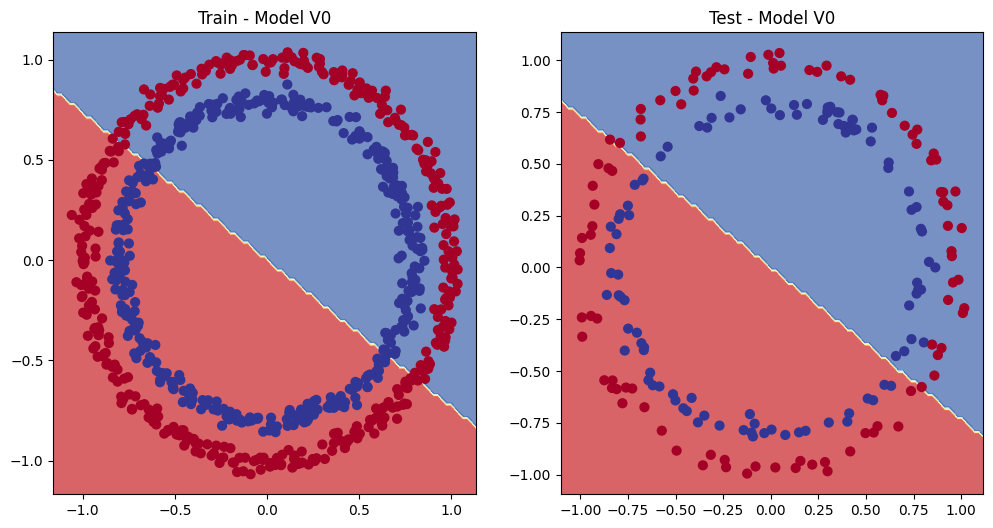

In [12]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")
    # Setup meshgrid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101),
    np.linspace(y_min, y_max, 101))
    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(),
    yy.ravel()))).float()
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)
        if len(torch.unique(y)) > 2:
            y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
        else:
            y_pred = torch.round(torch.sigmoid(y_logits)) # binary
        y_pred = y_pred.reshape(xx.shape).detach().numpy()
        plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
        plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
        plt.xlim(xx.min(), xx.max())
        plt.ylim(yy.min(), yy.max())

def plot_loss_curves(train_losses, test_losses):
    plt.figure(figsize=(8, 5))
    plt.plot(range(len(train_losses)), train_losses, label="Train Loss")
    plt.plot(range(len(test_losses)), test_losses, label="Test Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

class ModelV0(nn.Module):
 def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

 def forward(self, x):
    return self.layer_2(self.layer_1(x))
model_0 = ModelV0().to(device)
# Optimizer & Loss
loss_fn = nn.BCEWithLogitsLoss()
optimizer_0 = torch.optim.SGD(params=model_0.parameters(), lr=0.1)
# Train
train_loss_0, test_loss_0 = train_and_test_loop(
  model_0, 100, loss_fn, optimizer_0, "ModelV0"
)
# Plot Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train - Model V0")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test - Model V0")
plot_decision_boundary(model_0, X_test, y_test)
plt.show()

ModelV1: 2 -> 15 -> 15 -> 1 (No Activation)


Training ModelV1 for 1000 epochs...
Epoch: 0 | Loss: 0.69556, Acc: 47.25% | Test Loss: 0.69913, Test Acc: 49.00%
Epoch: 100 | Loss: 0.69307, Acc: 50.25% | Test Loss: 0.69425, Test Acc: 48.50%
Epoch: 200 | Loss: 0.69300, Acc: 51.12% | Test Loss: 0.69441, Test Acc: 47.00%
Epoch: 300 | Loss: 0.69299, Acc: 51.25% | Test Loss: 0.69454, Test Acc: 46.00%
Epoch: 400 | Loss: 0.69298, Acc: 51.62% | Test Loss: 0.69461, Test Acc: 46.00%
Epoch: 500 | Loss: 0.69298, Acc: 51.00% | Test Loss: 0.69464, Test Acc: 45.50%
Epoch: 600 | Loss: 0.69298, Acc: 51.25% | Test Loss: 0.69466, Test Acc: 45.50%
Epoch: 700 | Loss: 0.69298, Acc: 51.25% | Test Loss: 0.69467, Test Acc: 46.00%
Epoch: 800 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69467, Test Acc: 46.00%
Epoch: 900 | Loss: 0.69298, Acc: 51.12% | Test Loss: 0.69468, Test Acc: 46.00%


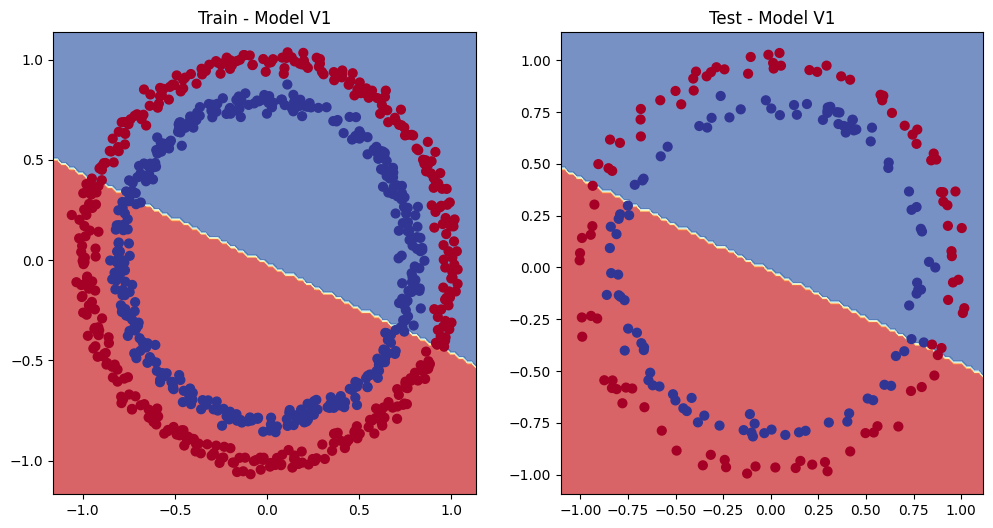

In [13]:
class ModelV1(nn.Module):
 def __init__(self):
  super().__init__()
  self.layer_1 = nn.Linear(in_features=2, out_features=15)
  self.layer_2 = nn.Linear(in_features=15, out_features=15)
  self.layer_3 = nn.Linear(in_features=15, out_features=1)

 def forward(self, x):
  return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = ModelV1().to(device)
optimizer_1 = torch.optim.SGD(params=model_1.parameters(), lr=0.1)
# Train
train_loss_1, test_loss_1 = train_and_test_loop(
 model_1, 1000, loss_fn, optimizer_1, "ModelV1"
)
# Plot Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train - Model V1")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test - Model V1")
plot_decision_boundary(model_1, X_test, y_test)
plt.show()

ModelV2: 2 -> 64 -> 64 -> 10 -> 1


Training ModelV2 for 1500 epochs...
Epoch: 0 | Loss: 0.70336, Acc: 50.00% | Test Loss: 0.70294, Test Acc: 50.00%
Epoch: 150 | Loss: 0.68906, Acc: 60.88% | Test Loss: 0.68962, Test Acc: 60.50%
Epoch: 300 | Loss: 0.67677, Acc: 64.25% | Test Loss: 0.67921, Test Acc: 61.00%
Epoch: 450 | Loss: 0.60093, Acc: 90.00% | Test Loss: 0.61132, Test Acc: 84.00%
Epoch: 600 | Loss: 0.40979, Acc: 73.88% | Test Loss: 0.47938, Test Acc: 61.50%
Epoch: 750 | Loss: 0.05262, Acc: 100.00% | Test Loss: 0.07945, Test Acc: 100.00%
Epoch: 900 | Loss: 0.01675, Acc: 100.00% | Test Loss: 0.03239, Test Acc: 100.00%
Epoch: 1050 | Loss: 0.00918, Acc: 100.00% | Test Loss: 0.02059, Test Acc: 100.00%
Epoch: 1200 | Loss: 0.00620, Acc: 100.00% | Test Loss: 0.01558, Test Acc: 100.00%
Epoch: 1350 | Loss: 0.00463, Acc: 100.00% | Test Loss: 0.01270, Test Acc: 100.00%


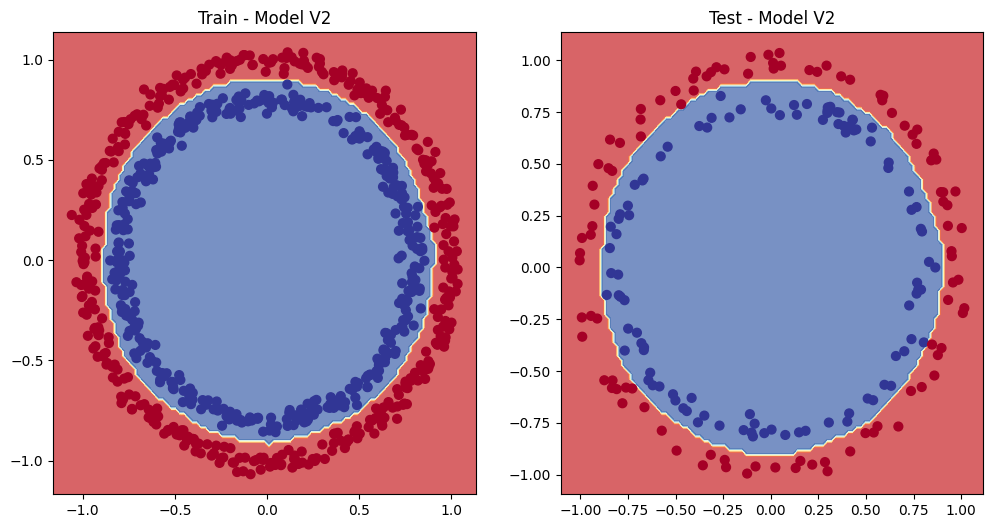

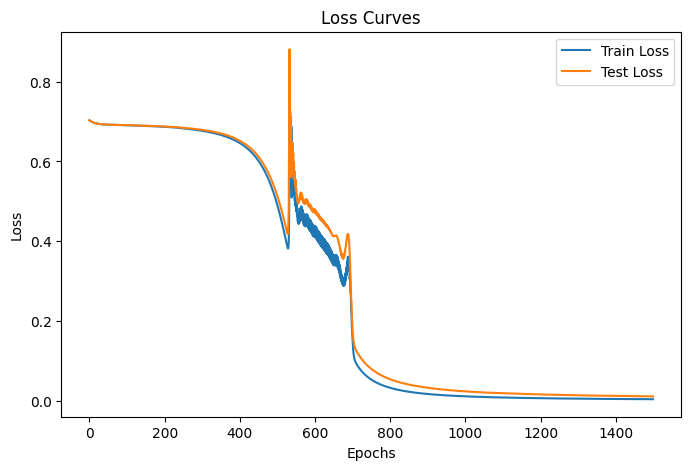

In [14]:
class ModelV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=64)
    self.layer_2 = nn.Linear(in_features=64, out_features=64)
    self.layer_3 = nn.Linear(in_features=64, out_features=10)
    self.layer_4 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU()

  def forward(self, x):
    x = self.relu(self.layer_1(x))
    x = self.relu(self.layer_2(x))
    x = self.relu(self.layer_3(x))
    return self.layer_4(x)
model_2 = ModelV2().to(device)
optimizer_2 = torch.optim.SGD(params=model_2.parameters(), lr=0.1)
# Train
train_loss_2, test_loss_2 = train_and_test_loop(
 model_2, 1500, loss_fn, optimizer_2, "ModelV2"
)
# Plot Results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train - Model V2")
plot_decision_boundary(model_2, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test - Model V2")
plot_decision_boundary(model_2, X_test, y_test)
plt.show()

plot_loss_curves(train_loss_2, test_loss_2)

# **Discussion**

ModelV0:
This basic model only uses linear layers. It can draw only a straight line, so it cannot separate circular data properly. That is why it gives around 50% accuracy and underfits.

ModelV1:
This model is bigger and deeper, but it still does not use activation functions. Even with more layers, it still behaves like a linear model. So, it still cannot learn circular patterns and gives about 50% accuracy.

ModelV2:
This model uses ReLU activation. ReLU allows the model to learn curved and complex shapes. Because of this, it can correctly separate the circles and achieves very high accuracy (above 95%).

# **Conclusion**

In sconclusion, when data has curved or complex patterns like circles or moons, we must use activation functions such as ReLU, Tanh, or Sigmoid. Just making the network bigger or deeper is not enough. Without activation functions, the model will still behave like a straight-line model and will not learn complex patterns properly.